# 22 · 정제 피처 리텐션 모델

**한 줄 답:** 이전 게이트에서 킵한 `early_tracked_events` 신호를 운영 피처 후보로 정제한다. 원시 이벤트 수만 쓰지 않고, 첫 10분의 의도행동·자동/세션·진입·접속·행동 다양성을 나눠서 모델에 넣는다.

**타깃:** `later_active` = 첫 관측 후 10분~24시간 안에 의도적 행동이 1회 이상 있는가.

**표본:** 2026-09-04~2026-09-11 KST 신규 기기, 24시간 라벨 창 완료, beta_A/B 표시 기기 제외. A/B 효과는 보지 않는다.

**사전 기준:**

- refined model AUC가 majority 0.50과 channel baseline보다 높고, PR-AUC가 raw `early_tracked_events` baseline 대비 80% 이상이면 피처셋 채택 후보.
- raw `early_tracked_events`가 계속 1위면 원시 신호를 버리지 않는다. 대신 refined model의 계수와 점수를 세그먼트 유도 로직 설명에 쓴다.
- 95대/양성 12대이므로 운영 배포, 계수 export, threshold 확정은 하지 않는다.

**부스팅 보류:** XGBoost/LightGBM은 표본이 늘면 다시 본다. 지금은 양성 12대라 튜닝 자유도가 큰 모델보다 regularized logistic이 더 정직하다.

## 1. 데이터와 누수 차단

입력 feature table은 BigQuery에서 만든 `ml/sql/g5_refined_retention_feature_table.sql` 결과다. `later_*` 컬럼은 라벨/검산에만 쓰고 학습 입력에서 제외한다.

In [1]:
from pathlib import Path
import json
import os, sys

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, balanced_accuracy_score, precision_recall_curve, roc_auc_score
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parents[1]
os.chdir(ROOT)
sys.path.insert(0, str(ROOT / 'ml'))

from calm_ml import report as R

R.setup()
OUT = ROOT / 'ml/reports/g5_refined_retention_model_2026-09-15'
OUT.mkdir(parents=True, exist_ok=True)
SRC = OUT / 'refined_retention_feature_table.csv'

def bootstrap_ci(y, p, metric, n_boot=5000, seed=22):
    rng = np.random.default_rng(seed)
    idx = np.arange(len(y))
    vals = []
    for _ in range(n_boot):
        s = rng.choice(idx, size=len(idx), replace=True)
        if len(np.unique(y[s])) < 2:
            continue
        vals.append(metric(y[s], p[s]))
    return float(np.percentile(vals, 2.5)), float(np.percentile(vals, 97.5))

def make_preprocessor(num_cols, cat_cols):
    return ColumnTransformer([
        ('num', Pipeline([
            ('impute', SimpleImputer(strategy='median')),
            ('scale', StandardScaler()),
        ]), num_cols),
        ('cat', Pipeline([
            ('impute', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore', min_frequency=2)),
        ]), cat_cols),
    ], remainder='drop')

def cv_predict(df, y, num_cols, cat_cols, C=0.2):
    pipe = Pipeline([
        ('prep', make_preprocessor(num_cols, cat_cols)),
        ('clf', LogisticRegression(
            penalty='l2',
            C=C,
            class_weight='balanced',
            solver='liblinear',
            max_iter=1000,
            random_state=22,
        )),
    ])
    cv = RepeatedStratifiedKFold(n_splits=4, n_repeats=50, random_state=22)
    X = df[num_cols + cat_cols]
    pred_sum = np.zeros(len(y), dtype=float)
    pred_count = np.zeros(len(y), dtype=float)
    for tr, te in cv.split(X, y):
        fold_pipe = clone(pipe)
        fold_pipe.fit(X.iloc[tr], y[tr])
        pred_sum[te] += fold_pipe.predict_proba(X.iloc[te])[:, 1]
        pred_count[te] += 1
    p = pred_sum / pred_count
    pipe.fit(X, y)
    return p, pipe

def feature_names(pipe):
    prep = pipe.named_steps['prep']
    try:
        return prep.get_feature_names_out()
    except Exception:
        return np.array([])


In [2]:
d = pd.read_csv(SRC)
d['y'] = d.later_active.astype(bool).astype(int)
d['is_toss_observed'] = (d.channel_segment == '토스 관측').astype(int)
d['is_mobile'] = (d.device == 'mobile').astype(int)
d['is_south_korea'] = (d.country_group == 'South Korea').astype(int)

count_cols = [c for c in d.columns if c.startswith('early_') and c.endswith('_events')]
for col in count_cols + ['early_tracked_events', 'early_actions', 'early_action_kinds', 'early_area_count', 'early_event_name_count']:
    d[f'log_{col}'] = np.log1p(d[col])

blocked = [c for c in d.columns if c.startswith('later_')]
assert len(d) == 95
assert int(d.y.sum()) == 12
assert int(d.feature_boundary_violations.sum()) == 0
assert int(d.label_boundary_violations.sum()) == 0
assert d.device_label.is_unique

print('n=', len(d), 'positive=', int(d.y.sum()), 'rate=', f'{d.y.mean():.1%}')
print('blocked later columns:', blocked)
display(d[['device_label', 'split_segment', 'early_tracked_events', 'early_actions', 'deliberate_share', 'later_active']].head(12))


n= 95 positive= 12 rate= 12.6%
blocked later columns: ['later_actions', 'later_action_kinds', 'later_area_count', 'later_nature_events', 'later_fishing_sea_events', 'later_quest_social_events', 'later_craft_home_events', 'later_advanced_events', 'later_active']


,device_label,split_segment,early_tracked_events,early_actions,deliberate_share,later_active
0,D001,고밀도+의도행동 많음,184,111,0.603261,True
1,D002,고밀도+의도행동 많음,41,7,0.170732,True
2,D003,저밀도+의도행동 없음,4,0,0.000000,False
3,D004,저밀도+의도행동 없음,4,0,0.000000,False
4,D005,저밀도+의도행동 없음,3,0,0.000000,False
5,D006,저밀도+의도행동 없음,7,0,0.000000,False
6,D007,저밀도+의도행동 없음,5,0,0.000000,False
7,D008,고밀도+의도행동 많음,230,100,0.434783,True
8,D009,고밀도+의도행동 많음,165,88,0.533333,True
9,D010,저밀도+의도행동 없음,5,0,0.000000,False


## 2. 비교할 모델

baseline은 일부러 단순하게 둔다. 모델 후보는 운영에 설명 가능한 묶음만 쓴다.

In [3]:
behavior_core = [
    'log_early_tracked_events',
    'log_early_actions',
    'deliberate_share',
    'log_early_action_kinds',
    'log_early_area_count',
    'log_early_event_name_count',
    'log_early_ga_auto_events',
    'log_early_entry_auth_events',
    'log_early_connect_ok_events',
    'log_early_connect_fail_events',
    'log_early_other_tracking_events',
    'ga_auto_share',
    'entry_auth_share',
    'other_tracking_share',
    'log_early_nature_events',
    'log_early_fishing_sea_events',
    'log_early_quest_social_events',
    'log_early_craft_home_events',
    'log_early_advanced_events',
]

named_event_counts = [
    'log_early_chop_tree_events',
    'log_early_mine_ore_events',
    'log_early_npc_talk_events',
    'log_early_tutorial_step_events',
    'log_early_quest_offered_events',
    'log_early_churn_score_events',
    'log_early_session_summary_events',
    'log_early_session_time_events',
    'log_early_econ_tx_events',
    'log_early_zone_enter_events',
]

profile = ['is_toss_observed', 'is_mobile', 'is_south_korea']

feature_sets = {
    'refined_behavior': (behavior_core, []),
    'refined_behavior_plus_named_events': (behavior_core + named_event_counts, []),
    'refined_plus_profile': (profile + behavior_core, ['acquisition_source']),
}

y = d.y.to_numpy()
rows = []
preds = {}
models = {}

majority_p = np.repeat(y.mean(), len(y))
rows.append({
    'model': 'majority_prevalence',
    'kind': 'baseline',
    'features': 0,
    'auc': 0.5,
    'auc_ci_low': 0.5,
    'auc_ci_high': 0.5,
    'pr_auc': float(average_precision_score(y, majority_p)),
    'balanced_acc_at_top_30pct': 0.5,
})

raw_baselines = {
    'channel_raw_rank': d.is_toss_observed.to_numpy(),
    'early_actions_raw_rank': d.early_actions.to_numpy(),
    'early_tracked_raw_rank': d.early_tracked_events.to_numpy(),
    'deliberate_share_raw_rank': d.deliberate_share.to_numpy(),
}
for name, score in raw_baselines.items():
    auc = float(roc_auc_score(y, score))
    ci_low, ci_high = bootstrap_ci(y, score, roc_auc_score)
    cutoff = np.quantile(score, 0.70)
    pred_label = (score >= cutoff).astype(int)
    rows.append({
        'model': name,
        'kind': 'raw_rank_baseline',
        'features': 1,
        'auc': auc,
        'auc_ci_low': ci_low,
        'auc_ci_high': ci_high,
        'pr_auc': float(average_precision_score(y, score)),
        'balanced_acc_at_top_30pct': float(balanced_accuracy_score(y, pred_label)),
    })
    preds[name] = score

for name, (num_cols, cat_cols) in feature_sets.items():
    p, model = cv_predict(d, y, num_cols, cat_cols)
    auc = float(roc_auc_score(y, p))
    ci_low, ci_high = bootstrap_ci(y, p, roc_auc_score)
    cutoff = np.quantile(p, 0.70)
    pred_label = (p >= cutoff).astype(int)
    rows.append({
        'model': name,
        'kind': 'cv_logistic',
        'features': len(num_cols) + len(cat_cols),
        'auc': auc,
        'auc_ci_low': ci_low,
        'auc_ci_high': ci_high,
        'pr_auc': float(average_precision_score(y, p)),
        'balanced_acc_at_top_30pct': float(balanced_accuracy_score(y, pred_label)),
    })
    preds[name] = p
    models[name] = model

metrics = pd.DataFrame(rows).sort_values(['auc', 'pr_auc'], ascending=False)
metrics.to_csv(OUT / 'refined_model_metrics.csv', index=False)
display(metrics)


/Users/uicheol_hwang/calm_forest/ml/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/uicheol_hwang/calm_forest/ml/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/Use

/Users/uicheol_hwang/calm_forest/ml/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/uicheol_hwang/calm_forest/ml/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/Use

/Users/uicheol_hwang/calm_forest/ml/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/uicheol_hwang/calm_forest/ml/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/Use

/Users/uicheol_hwang/calm_forest/ml/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/uicheol_hwang/calm_forest/ml/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/Use

/Users/uicheol_hwang/calm_forest/ml/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/uicheol_hwang/calm_forest/ml/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/Use

...

/Users/uicheol_hwang/calm_forest/ml/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/uicheol_hwang/calm_forest/ml/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/Use

/Users/uicheol_hwang/calm_forest/ml/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/uicheol_hwang/calm_forest/ml/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/Use

/Users/uicheol_hwang/calm_forest/ml/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/uicheol_hwang/calm_forest/ml/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/Use

/Users/uicheol_hwang/calm_forest/ml/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/uicheol_hwang/calm_forest/ml/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/Use

,model,kind,features,auc,auc_ci_low,auc_ci_high,pr_auc,balanced_acc_at_top_30pct
6,refined_behavior_plus_named_events,cv_logistic,29,0.927711,0.792716,0.998918,0.849379,0.849900
5,refined_behavior,cv_logistic,19,0.914659,0.766234,0.995294,0.821900,0.849900
7,refined_plus_profile,cv_logistic,23,0.914659,0.772936,0.995310,0.817487,0.849900
3,early_tracked_raw_rank,raw_rank_baseline,1,0.883032,0.776014,0.965517,0.665163,0.802209
2,early_actions_raw_rank,raw_rank_baseline,1,0.760542,0.588949,0.916232,0.554332,0.500000
4,deliberate_share_raw_rank,raw_rank_baseline,1,0.757530,0.587662,0.912356,0.501922,0.500000
1,channel_raw_rank,raw_rank_baseline,1,0.604418,0.444184,0.741466,0.158047,0.604418
0,majority_prevalence,baseline,0,0.500000,0.500000,0.500000,0.126316,0.500000


g5_refined_retention_model_auc.png  1343x671px


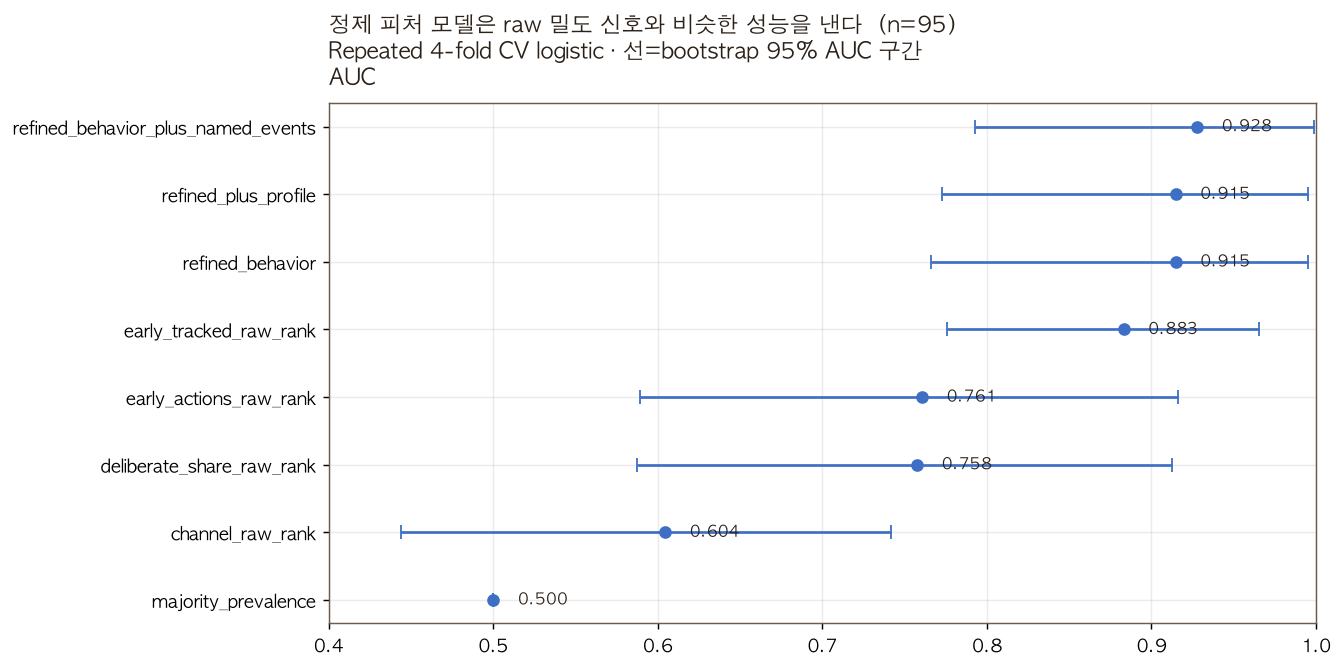

In [4]:
fig, ax = R.new(
    '정제 피처 모델은 raw 밀도 신호와 비슷한 성능을 낸다',
    len(d),
    sub='Repeated 4-fold CV logistic · 선=bootstrap 95% AUC 구간',
    ylab='AUC',
    figsize=(9.8, 5.2),
)
plot = metrics.sort_values('auc')
ypos = np.arange(len(plot))
ax.errorbar(
    plot.auc,
    ypos,
    xerr=[plot.auc - plot.auc_ci_low, plot.auc_ci_high - plot.auc],
    fmt='o',
    color=R.PALETTE[1],
    capsize=4,
)
ax.set_yticks(ypos, plot.model)
ax.set_xlim(0.40, 1.0)
for i, row in enumerate(plot.itertuples()):
    ax.text(min(row.auc + 0.015, 0.98), i, f'{row.auc:.3f}', va='center', fontsize=9)
chart_auc = R.save(fig, ax, 'g5_refined_retention_model_auc', zero_base=False)
print(R.check(chart_auc))
display(R.show(chart_auc))


## 3. 선택 모델의 계수

운영 후보 설명에는 `refined_behavior`를 우선 본다. 프로필과 유입 source는 날짜/채널 편향을 먹기 쉬워 보조로만 둔다.

In [5]:
selected = 'refined_behavior'
model = models[selected]
names = feature_names(model)
coefs = model.named_steps['clf'].coef_[0]
coef_df = pd.DataFrame({'feature': names, 'coef': coefs})
coef_df['abs_coef'] = coef_df.coef.abs()
coef_df = coef_df.sort_values('abs_coef', ascending=False)
coef_df.to_csv(OUT / 'refined_behavior_coefficients.csv', index=False)
display(coef_df.head(20))


,feature,coef,abs_coef
6,num__log_early_ga_auto_events,0.846177,0.846177
18,num__log_early_advanced_events,0.474269,0.474269
7,num__log_early_entry_auth_events,0.445895,0.445895
15,num__log_early_fishing_sea_events,0.407545,0.407545
12,num__entry_auth_share,0.383028,0.383028
9,num__log_early_connect_fail_events,-0.303872,0.303872
0,num__log_early_tracked_events,0.264843,0.264843
14,num__log_early_nature_events,0.264633,0.264633
8,num__log_early_connect_ok_events,0.237569,0.237569
4,num__log_early_area_count,-0.214727,0.214727


g5_refined_retention_model_coefficients.png  1254x731px


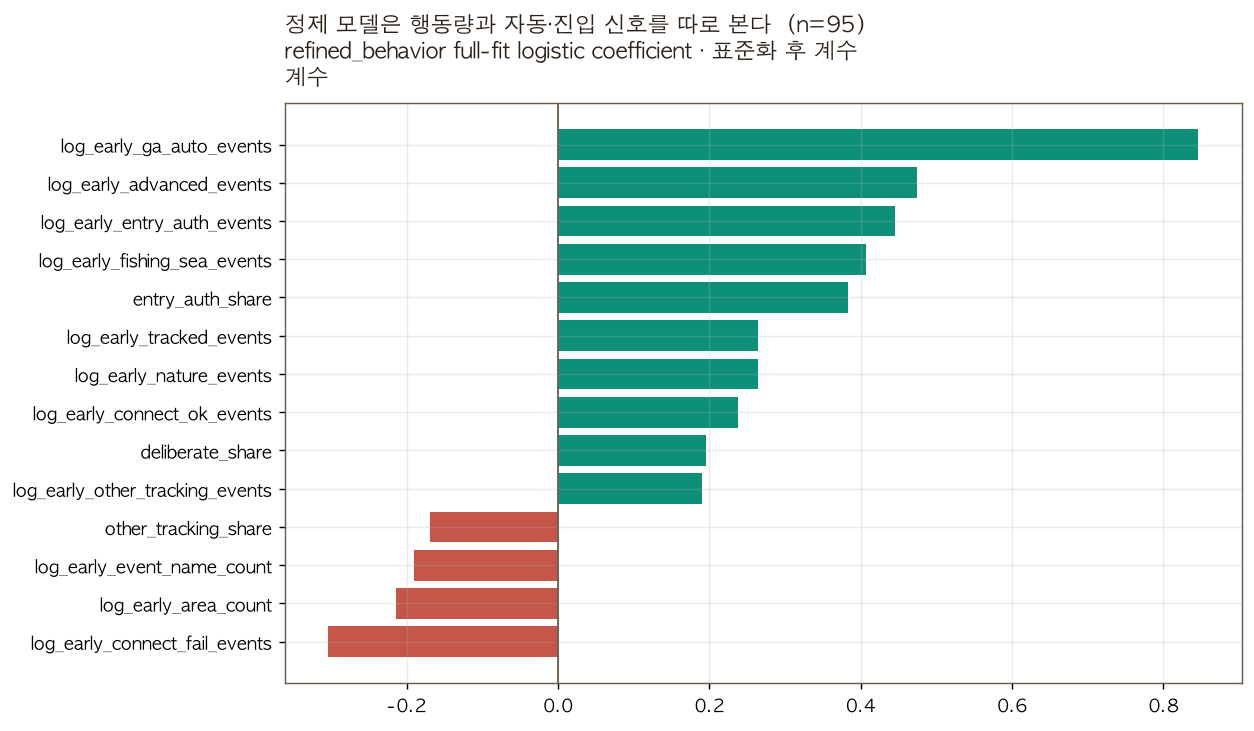

In [6]:
top = coef_df.head(14).sort_values('coef')
fig, ax = R.new(
    '정제 모델은 행동량과 자동·진입 신호를 따로 본다',
    len(d),
    sub='refined_behavior full-fit logistic coefficient · 표준화 후 계수',
    ylab='계수',
    figsize=(9.5, 5.8),
)
colors = [R.PALETTE[2] if v > 0 else R.PALETTE[0] for v in top.coef]
ax.barh(np.arange(len(top)), top.coef, color=colors)
ax.set_yticks(np.arange(len(top)), top.feature.str.replace('num__', '', regex=False))
ax.axvline(0, color=R.MUTED, linewidth=1)
chart_coef = R.save(fig, ax, 'g5_refined_retention_model_coefficients', zero_base=False)
print(R.check(chart_coef))
display(R.show(chart_coef))


## 4. 점수와 개입 후보 크기

운영 threshold를 확정하지는 않는다. 다만 상위 30%를 표시하면 몇 대를 잡고, 양성을 얼마나 포함하는지 본다.

In [7]:
score_df = d[['device_label', 'split_segment', 'channel_segment', 'early_tracked_events', 'early_actions', 'deliberate_share', 'later_active']].copy()
for name, p in preds.items():
    score_df[name] = p
score_df['selected_score'] = preds[selected]
score_df['selected_rank'] = score_df.selected_score.rank(method='first', ascending=False).astype(int)
score_df.to_csv(OUT / 'refined_model_scores.csv', index=False)

threshold_rows = []
for frac in [0.20, 0.30, 0.40]:
    cutoff = score_df.selected_score.quantile(1 - frac)
    flagged = score_df.selected_score >= cutoff
    threshold_rows.append({
        'policy': f'top_{int(frac*100)}pct',
        'score_cutoff': float(cutoff),
        'flagged_devices': int(flagged.sum()),
        'captured_positives': int(score_df.loc[flagged, 'later_active'].astype(bool).sum()),
        'precision': float(score_df.loc[flagged, 'later_active'].astype(bool).mean()),
        'recall': float(score_df.loc[flagged, 'later_active'].astype(bool).sum() / score_df.later_active.astype(bool).sum()),
    })
thresholds = pd.DataFrame(threshold_rows)
thresholds.to_csv(OUT / 'refined_model_thresholds.csv', index=False)
display(thresholds)
display(score_df.sort_values('selected_score', ascending=False).head(15))


,policy,score_cutoff,flagged_devices,captured_positives,precision,recall
0,top_20pct,0.520587,19,10,0.526316,0.833333
1,top_30pct,0.359434,29,11,0.379310,0.916667
2,top_40pct,0.262688,38,11,0.289474,0.916667


,device_label,split_segment,channel_segment,early_tracked_events,early_actions,deliberate_share,later_active,channel_raw_rank,early_actions_raw_rank,early_tracked_raw_rank,deliberate_share_raw_rank,refined_behavior,refined_behavior_plus_named_events,refined_plus_profile,selected_score,selected_rank
7,D008,고밀도+의도행동 많음,토스 관측,230,100,0.434783,True,1,100,230,0.434783,0.986239,0.936160,0.983233,0.986239,1
71,D072,고밀도+의도행동 적음,메인·웹만,28,0,0.000000,True,0,0,28,0.000000,0.979808,0.973190,0.980688,0.979808,2
10,D011,고밀도+의도행동 많음,토스 관측,310,219,0.706452,True,1,219,310,0.706452,0.930496,0.989812,0.927074,0.930496,3
43,D044,고밀도+의도행동 많음,토스 관측,42,14,0.333333,True,1,14,42,0.333333,0.927720,0.797735,0.912795,0.927720,4
40,D041,고밀도+의도행동 적음,메인·웹만,103,1,0.009709,True,0,1,103,0.009709,0.926127,0.844206,0.948686,0.926127,5
1,D002,고밀도+의도행동 많음,메인·웹만,41,7,0.170732,True,0,7,41,0.170732,0.910830,0.894398,0.929445,0.910830,6
12,D013,고밀도+의도행동 많음,토스 관측,143,76,0.531469,True,1,76,143,0.531469,0.909524,0.982614,0.918315,0.909524,7
0,D001,고밀도+의도행동 많음,토스 관측,184,111,0.603261,True,1,111,184,0.603261,0.825200,0.971239,0.826508,0.825200,8
66,D067,고밀도+의도행동 적음,토스 관측,61,5,0.081967,False,1,5,61,0.081967,0.758549,0.799403,0.724020,0.758549,9
67,D068,고밀도+의도행동 많음,토스 관측,90,38,0.422222,False,1,38,90,0.422222,0.739148,0.603842,0.686380,0.739148,10


g5_refined_retention_model_scores.png  949x660px


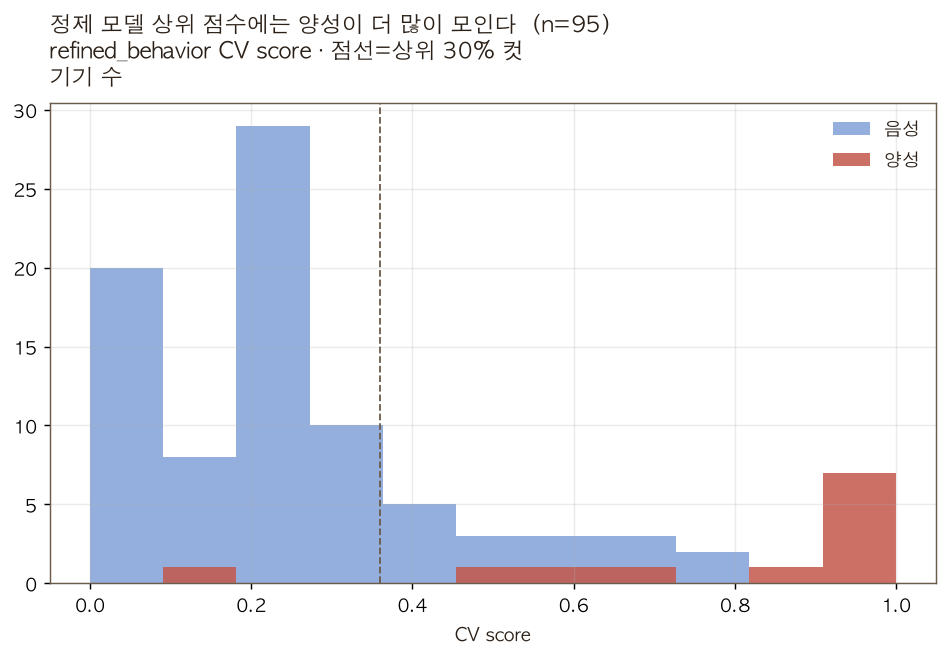

In [8]:
plot_score = score_df.copy()
fig, ax = R.new(
    '정제 모델 상위 점수에는 양성이 더 많이 모인다',
    len(d),
    sub='refined_behavior CV score · 점선=상위 30% 컷',
    ylab='기기 수',
    figsize=(8.8, 4.8),
)
neg = plot_score.loc[~plot_score.later_active.astype(bool), 'selected_score']
pos = plot_score.loc[plot_score.later_active.astype(bool), 'selected_score']
bins = np.linspace(0, 1, 12)
ax.hist(neg, bins=bins, color=R.tint(R.PALETTE[1], 0.35), label='음성', alpha=0.85)
ax.hist(pos, bins=bins, color=R.PALETTE[0], label='양성', alpha=0.85)
ax.axvline(plot_score.selected_score.quantile(0.70), color=R.MUTED, linestyle='--', linewidth=1)
ax.set_xlabel('CV score')
ax.legend(frameon=False)
chart_scores = R.save(fig, ax, 'g5_refined_retention_model_scores', zero_base=True)
print(R.check(chart_scores))
display(R.show(chart_scores))


## 5. 판정

정제 피처셋은 채택 후보로 둔다. raw `early_tracked_events`는 여전히 강하지만, 원시 수만으로는 자동·세션·진입 이벤트와 실제 플레이 행동이 섞인다. 따라서 다음 파이프라인은 `refined_behavior`를 기본형으로 쓰고, raw 밀도 기준은 비교 baseline과 rule fallback으로만 둔다.

**이 숫자로 말할 수 없는 것:** 표본은 95대, 양성은 12대라 운영 threshold와 계수 안정성을 확정할 수 없다. bootstrap 구간이 넓고, 같은 날짜·유입·시설 업데이트 효과가 섞여 있다. A/B 효과는 이번 분석에 포함하지 않았다.

**다음에 확인할 것:** 며칠 더 쌓이면 같은 SQL을 재실행해 `refined_behavior`의 AUC/PR-AUC와 top 30% precision이 유지되는지 본다. 유지되면 그때 G6 적용 설계로 넘어간다.

In [9]:
summary = {
    'date': '2026-09-15',
    'sample': {'devices': int(len(d)), 'positives': int(d.y.sum()), 'positive_rate': float(d.y.mean())},
    'target': 'later_active: first 10m excluded, 10m-24h deliberate action',
    'excluded': 'marked beta tester devices where GA4 user_properties.ab_variant matches beta_A/beta_B',
    'not_used': ['A/B variant effect', 'later_* columns as features', 'raw identifiers'],
    'selected_model': selected,
    'criteria': 'candidate if above majority/channel and PR-AUC >= 80% of raw early_tracked baseline',
    'metrics': metrics.to_dict(orient='records'),
}
with open(OUT / 'refined_model_assumptions.json', 'w', encoding='utf-8') as f:
    json.dump(summary, f, ensure_ascii=False, indent=2)
print(json.dumps(summary, ensure_ascii=False, indent=2)[:2200])


{
  "date": "2026-09-15",
  "sample": {
    "devices": 95,
    "positives": 12,
    "positive_rate": 0.12631578947368421
  },
  "target": "later_active: first 10m excluded, 10m-24h deliberate action",
  "excluded": "marked beta tester devices where GA4 user_properties.ab_variant matches beta_A/beta_B",
  "not_used": [
    "A/B variant effect",
    "later_* columns as features",
    "raw identifiers"
  ],
  "selected_model": "refined_behavior",
  "criteria": "candidate if above majority/channel and PR-AUC >= 80% of raw early_tracked baseline",
  "metrics": [
    {
      "model": "refined_behavior_plus_named_events",
      "kind": "cv_logistic",
      "features": 29,
      "auc": 0.927710843373494,
      "auc_ci_low": 0.7927159810126582,
      "auc_ci_high": 0.9989177489177489,
      "pr_auc": 0.8493788819875777,
      "balanced_acc_at_top_30pct": 0.8498995983935742
    },
    {
      "model": "refined_behavior",
      "kind": "cv_logistic",
      "features": 19,
      "auc": 0.914658634